# INSTITUTIONAL RISK MANAGEMENT ENGINE

A Python-based portfolio risk analytics engine implementing historical,
parametric, Monte Carlo, stress-testing, backtesting, risk decomposition,
and risk-reporting techniques.

The project uses a three-asset equity portfolio to demonstrate how
different risk models can be implemented, compared, and integrated into
a unified risk-monitoring workflow.

## 1. DATA & PORTFOLIO FOUNDATION
>Objective: Build the market-data and portfolio-return foundation used by the downstream risk models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats

def get_market_data(tickers, period='5y'):
  price = yf.download(tickers, period=period, auto_adjust=True, progress=False)['Close']
  valid_count = price.notna().sum()

  if valid_count.min() < 0.9 * valid_count.max():
    print(f' Warning Uneven data history - {valid_count}')

  price = price.dropna()
  print(f'\nUsing {len(price)} trading days: {price.index.min().date()} to {price.index.max().date()}')

  daily_returns = price.pct_change().dropna()
  N = daily_returns.shape[1]
  equal_weights = np.repeat(1/N, N)
  port_returns = daily_returns @ equal_weights

  return daily_returns, port_returns, equal_weights, N


## 2. HISTORICAL VaR & CVaR (EXPECTED SHORTFALL)
>Objective: Estimate one-day downside risk using historical Value at Risk and Conditional Value at Risk.

In [2]:
def historical_var_and_cvar(returns, c=0.95):
  p = 1 - c
  var = np.quantile(returns, p)
  cvar = returns[returns <= var].mean()
  return abs(var), abs(cvar)

## 3. PARAMETRIC MONTE CARLO SIMULATION
>Objective: Estimate portfolio risk under a parametric normal-return assumption using Monte Carlo simulation.

In [3]:
def basic_monte_carlo(returns, random_seed=42, n_sim=10_000):
  daily_means = returns.mean()
  daily_std = returns.std()
  rng = np.random.default_rng(random_seed)
  Z = rng.normal(0, 1, n_sim)
  simulated_returns = daily_means + (Z * daily_std)
  return simulated_returns

## 4. CORRELATED MONTE CARLO WITH CHOLESKY DECOMPOSITION
>Objective: Preserve cross-asset dependence by generating correlated asset-return scenarios using Cholesky decomposiiton.

In [4]:
def cholesky_monte_carlo(returns, weights, N, random_seed=42, n_sim=10_000):
  daily_means = returns.mean()
  covariance_matrix = returns.cov()
  rng = np.random.default_rng(random_seed)
  Z = rng.normal(0, 1, (n_sim, N))
  L = np.linalg.cholesky(covariance_matrix)
  R = daily_means.values + (Z @ L.T)
  simulated_returns = R @ weights
  return simulated_returns

## 5. DATA INGESTION & CONFIGURATION

In [5]:
tickers = ['NVDA', 'GOOG', 'AAPL']
daily_returns, port_returns, equal_weights, n_tickers = get_market_data(tickers)

# -- Historical metrics --
var, cvar = historical_var_and_cvar(port_returns)

# -- Parametric Monte Carlo (Portfolio level) --
basic_mc_returns = basic_monte_carlo(port_returns)
basic_mc_var, basic_mc_cvar = historical_var_and_cvar(basic_mc_returns)

# -- Cholesky Monte Carlo (Multi-asset correlated)
chl_mc_returns = cholesky_monte_carlo(daily_returns, equal_weights, n_tickers)
chl_mc_var, chl_mc_cvar = historical_var_and_cvar(chl_mc_returns)

hist = var, cvar
basic_mc = basic_mc_var, basic_mc_cvar
chl_mc = chl_mc_var, chl_mc_cvar

raw = np.vstack([hist, basic_mc, chl_mc])
var_cvar_summary = pd.DataFrame(
    raw,
    columns=['95% VaR', '95% CVaR'],
    index=['Historical 1-Day', 'Basic Monte Carlo 1-Day', 'Cholesky Monte Carlo 1-Day']
)

var_cvar_summary.style.format('{:,.2%}')


Using 1254 trading days: 2021-09-27 to 2026-09-24


,95% VaR,95% CVaR
Historical 1-Day,3.01%,4.20%
Basic Monte Carlo 1-Day,3.10%,3.91%
Cholesky Monte Carlo 1-Day,3.11%,3.84%


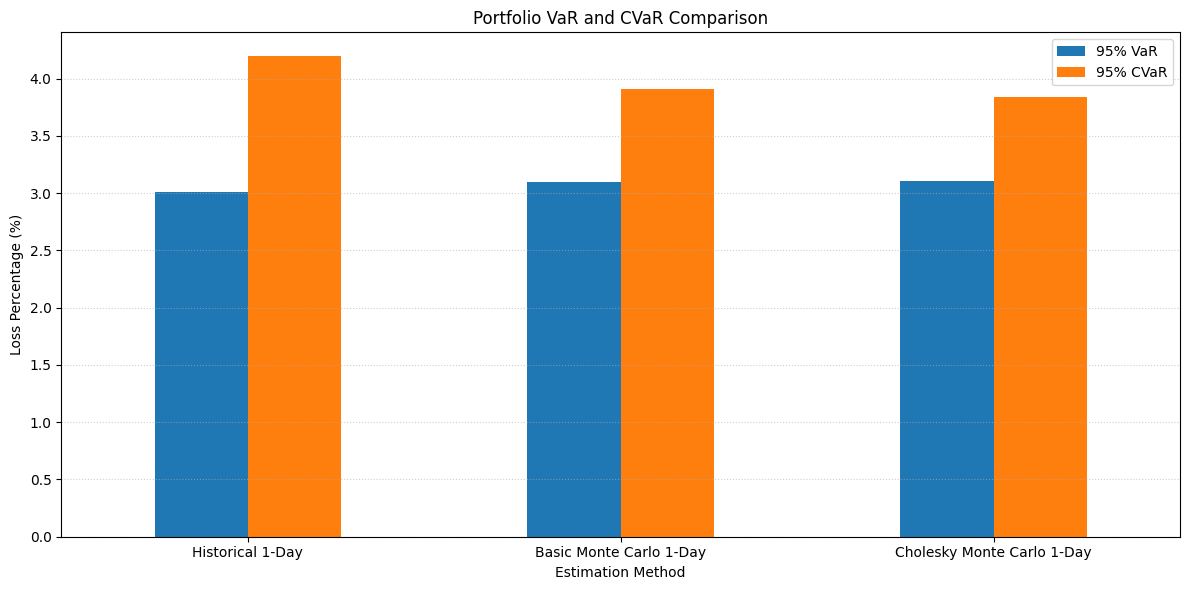

In [6]:
# -- VaR/CVaR Chart Comparison --

(var_cvar_summary * 100).plot(kind='bar', rot=0, figsize=(12, 6))

plt.title('Portfolio VaR and CVaR Comparison')
plt.ylabel('Loss Percentage (%)')
plt.xlabel('Estimation Method')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

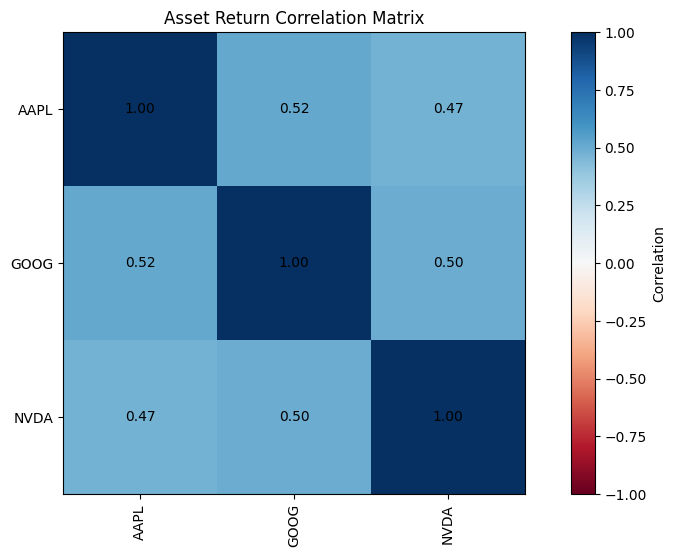

In [7]:
# -- Correlation Matrix --

plt.figure(figsize=(12, 6))

correlation_matrix = daily_returns.corr()
plt.imshow(correlation_matrix, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title('Asset Return Correlation Matrix')
for (i, j), val in np.ndenumerate(correlation_matrix):
    plt.text(j, i, f"{val:.2f}", ha="center", va="center")
plt.show()

## 6. MULTI-PATH MONTE CARLO SIMULATION
>Objective: Extend one-day Monte Carlo simulation into multi-day portfolio paths and evaluate path-dependent risks such as terminal loss and maximum drawdown.

In [8]:
def multi_path_monte_carlo(returns, weights, N, random_seed=42, n_sim=10_000):
  rng = np.random.default_rng(random_seed)
  n_trading = 252
  Z = rng.normal(0, 1, (n_sim, n_trading, N))
  daily_means = returns.mean()
  covariance_matrix = returns.cov()
  L = np.linalg.cholesky(covariance_matrix)
  R = daily_means.values + (Z @ L.T)
  simulated_returns = R @ weights
  sim_wealth_path = (1 + simulated_returns).cumprod(axis=1)
  terminal_wealth = sim_wealth_path[:, -1]
  terminal_returns = terminal_wealth - 1
  return sim_wealth_path, terminal_returns


mc_wealth_path, mc_terminal_returns = multi_path_monte_carlo(daily_returns, equal_weights, n_tickers)
multi_mc_var, multi_mc_cvar = historical_var_and_cvar(mc_terminal_returns)

raw = np.hstack([multi_mc_var, multi_mc_cvar])

multi_path_summary =  pd.DataFrame({
    '95% VaR' : [multi_mc_var],
    '95% CVaR' : [multi_mc_cvar]
}, index=['Multi-Path 252-day Horizon'])

multi_path_summary.style.format('{:,.2%}')

,95% VaR,95% CVaR
Multi-Path 252-day Horizon,17.49%,27.46%


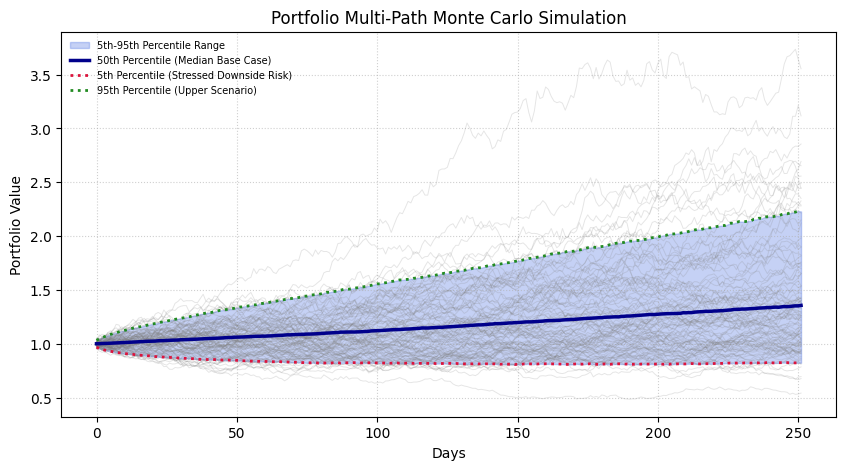

In [9]:
# -- Multi-Path Monte Carlo Fan Chart --

p5 = np.percentile(mc_wealth_path, 5, axis=0)
p50 = np.percentile(mc_wealth_path, 50, axis=0)
p95 = np.percentile(mc_wealth_path, 95, axis=0)
p_days = np.arange(mc_wealth_path.shape[1])

plt.figure(figsize=(10, 5))
plt.plot(p_days, mc_wealth_path[:100].T, color='gray', alpha=0.2, lw=0.7)
plt.fill_between(p_days, p5, p95, color='royalblue', alpha=0.3, label='5th-95th Percentile Range')

plt.plot(p_days, p50, c='darkblue', lw=2.5, label='50th Percentile (Median Base Case)')
plt.plot(p_days, p5, c='crimson', ls=':', lw=2, label='5th Percentile (Stressed Downside Risk)')
plt.plot(p_days, p95, c='forestgreen', ls=':', lw=2, label='95th Percentile (Upper Scenario)')

plt.title('Portfolio Multi-Path Monte Carlo Simulation')
plt.ylabel('Portfolio Value')
plt.xlabel('Days')
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc='best', fontsize=7, frameon=False)
plt.show()

## 7. HISTORICAL & MONTE CARLO MAXIMUM DRAWDOWN
>Objective: Measure historical and simulated peak-to-trough portfolio losses and assess drawdown severity.

### 7.1. HISTORICAL MAX DRAWDOWN

In [10]:
cum_growth = (1 + port_returns).cumprod()
peak = cum_growth.cummax()
drawdown = (cum_growth - peak) / peak
max_drawdown = drawdown.min()

print(f'The Maximum Drawdown for Historical Returns: {abs(max_drawdown):.2%}')

The Maximum Drawdown for Historical Returns: 42.13%


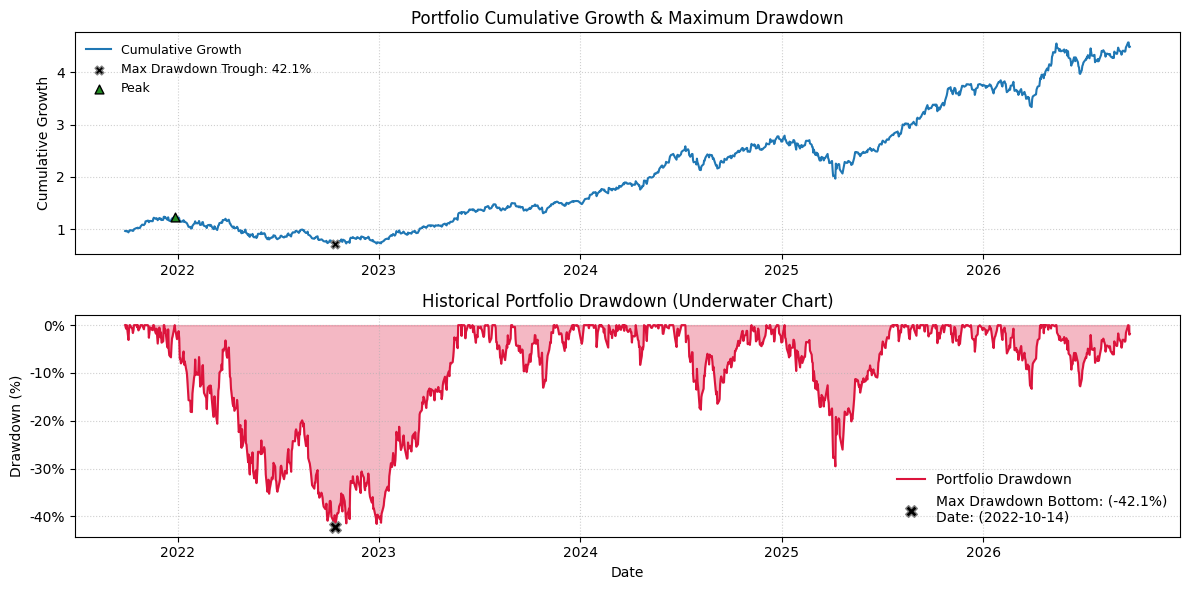

The Peak-to-Trough Duration: 291 days


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
# A. -- Portfolio Cumulative Growth --
trough_date = drawdown.idxmin()
trough_value = cum_growth.loc[trough_date]

peak_date = cum_growth.loc[:trough_date].idxmax()
peak_value = cum_growth.loc[peak_date]

ax1.plot(cum_growth, label='Cumulative Growth')
ax1.scatter(trough_date, trough_value, marker='X', s=40, color='black', edgecolor='gray',
            label=f'Max Drawdown Trough: {abs(max_drawdown*100):.1f}%', zorder=3)
ax1.scatter(peak_date, peak_value, marker='^', s=40, color='forestgreen',
            edgecolor='black', label='Peak', zorder=3)


ax1.set_title('Portfolio Cumulative Growth & Maximum Drawdown')
ax1.set_ylabel('Cumulative Growth')
ax1.legend(frameon=False, fontsize=9)
ax1.grid(True, linestyle=":", alpha=0.6)

# B. -- Drawdown --
ax2.plot(drawdown, color='crimson', label='Portfolio Drawdown')
ax2.fill_between(drawdown.index, 0, drawdown, color='crimson', alpha=0.3)
ax2.scatter(trough_date, max_drawdown, marker='X', s=70, color='black', edgecolor='gray', zorder=5,
         label=f'Max Drawdown Bottom: ({max_drawdown:.1%})\nDate: ({trough_date.strftime("%Y-%m-%d")})')

ax2.set_title('Historical Portfolio Drawdown (Underwater Chart)')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.legend(loc='lower right', frameon=False, fontsize=10)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

print(f'The Peak-to-Trough Duration: {(trough_date - peak_date).days} days')

### 7.2. MONTE CARLO MULTI-PATH MAX DRAWDOWN

In [12]:
running_peak = np.maximum.accumulate(mc_wealth_path, axis=1)
drawdown_path = (mc_wealth_path / running_peak) - 1
max_drawdowns = drawdown_path.min(axis=1)

mean_drawdown = max_drawdowns.mean()
median_drawdown = np.median(max_drawdowns)
worst_drawdown = max_drawdowns.min()

drawdown_95_threshold = np.quantile(max_drawdowns, 0.05)
probability_drawdown_30 = (max_drawdowns <= -0.30).mean()

print(f'Mean Maximum Drawdown: {abs(mean_drawdown):.2%}')
print(f'Median Drawdown: {abs(median_drawdown):.2%}')
print(f"Worst Simulated Drawdown: {abs(worst_drawdown):.2%}")
print(f"95% Maximum Drawdown: {abs(drawdown_95_threshold):.2%}")
print(f"Probability of Drawdown Worse Than 30%: {probability_drawdown_30:.2%}")

Mean Maximum Drawdown: 22.59%
Median Drawdown: 21.17%
Worst Simulated Drawdown: 60.39%
95% Maximum Drawdown: 37.56%
Probability of Drawdown Worse Than 30%: 16.79%


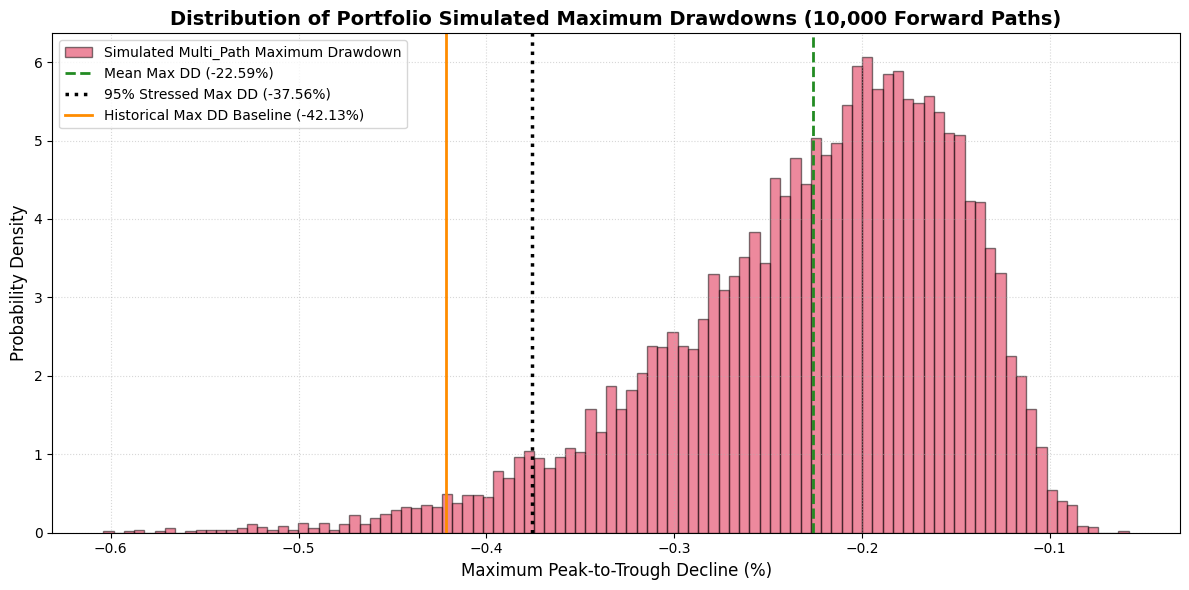

In [13]:
plt.figure(figsize=(12, 6))

plt.hist(max_drawdowns, bins=100, color='crimson', alpha=0.5, edgecolor='black', density=True,
         label='Simulated Multi_Path Maximum Drawdown')

plt.axvline(mean_drawdown, color='forestgreen', ls='--', lw=2,
            label=f'Mean Max DD ({mean_drawdown:.2%})')
plt.axvline(drawdown_95_threshold, color='black', ls=':', lw=2.5,
            label=f'95% Stressed Max DD ({drawdown_95_threshold:.2%})')

plt.axvline(max_drawdown, color='darkorange', lw=2,
            label=f'Historical Max DD Baseline ({max_drawdown:.2%})')

plt.title('Distribution of Portfolio Simulated Maximum Drawdowns (10,000 Forward Paths)',
          fontsize=14, fontweight='bold')
plt.xlabel('Maximum Peak-to-Trough Decline (%)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 8. SCENARIO-BASED STRESS TESTING
>Objective: Evaluate portfolio vulnerability under selected historical stress portfolio.

In [14]:
def get_scenario_data(tickers, start, end, weights):
  price = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)['Close']
  valid_count = price.notna().sum()
  if valid_count.min() < 0.9 * valid_count.max():
    print(f' Warning Uneven data history - {valid_count}')

  price = price.dropna()
  print(f'\nUsing {len(price)} trading days: {price.index.min().date()} to {price.index.max().date()}')

  daily_returns = price.pct_change().dropna()
  port_returns = daily_returns @ weights

  scenario_port_ret = port_returns.loc[start:end]

  scenario_worst_day = scenario_port_ret.min()
  scenario_best_day = scenario_port_ret.max()
  scenario_annual_vol = scenario_port_ret.std() * np.sqrt(252)

  scenario_growth = (1 + scenario_port_ret).cumprod()
  scenario_peak = scenario_growth.cummax()
  scenario_drawdown = (scenario_growth - scenario_peak) / scenario_peak
  scenario_max_drawdown = scenario_drawdown.min()

  scenario_total_return = scenario_growth.iloc[-1] - 1


  return {
      'total_return': scenario_total_return,
      'worst_day': scenario_worst_day,
      'best_day': scenario_best_day,
      'annual_vol': scenario_annual_vol,
      'max_drawdown': scenario_max_drawdown,
      'growth' : scenario_growth
  }

In [15]:
def calculate_recovery_time(growth):
  running_peak = growth.cummax()
  drawdown = (growth / running_peak) - 1

  trough_date = drawdown.idxmin()
  peak_date = growth.loc[:trough_date].idxmax()
  peak_value = growth.loc[peak_date]

  recovery_candidates = growth.loc[trough_date:]
  actual_recoveries = recovery_candidates[recovery_candidates >= peak_value]

  if len(actual_recoveries) == 0:
        recovery_date = None
        recovery_calendar_days = None
        recovery_trading_days = None
        has_recovered = False
  else:
        recovery_date = actual_recoveries.index[0]
        recovery_calendar_days = (recovery_date - peak_date).days
        recovery_trading_days = growth.loc[peak_date:recovery_date].shape[0] - 1
        has_recovered = True

  return {
      'maximum_drawdown': drawdown.min(),
      'peak_date': peak_date.date(),
      'trough_date': trough_date.date(),
      'recovery_date': recovery_date.date() if recovery_date is not None else None,
      'recovery_calendar_days': recovery_calendar_days,
      'recovery_trading_days': recovery_trading_days,
      'has_recovered': has_recovered
  }


In [16]:
scenarios = {
    '2008 Historical Crisis' : ('2008-01-01', '2009-01-01'),
    '2020 COVID Market Crash' : ('2020-01-01', '2021-01-01'),
    '2022 Inflation/Rate-Hike Shock' : ('2022-01-01', '2023-01-01')
}

metrics_mapping = {
    'total_return': 'Total Return',
    'worst_day': 'Worst Day',
    'best_day': 'Best Day',
    'annual_vol': 'Annual Volatility',
    'max_drawdown': 'Maximum Drawdown',
}

stress_summary = {}
recovery_summary = {}
scenario_results = {}

for name, (start, end) in scenarios.items():
  result = get_scenario_data(tickers, start, end, equal_weights)
  scenario_results[name] = result

  stress_summary[name] = {metrics_mapping[k] : result[k] for k in metrics_mapping if k in result}

  recovery = calculate_recovery_time(result['growth'])
  recovery_summary[name] = {k.replace('_', ' ').title() if k != 'recovered' else 'Recovered Within Scenario': v
                            for k, v in recovery.items()
                            }


Using 253 trading days: 2008-01-02 to 2008-12-31

Using 253 trading days: 2020-01-02 to 2020-12-31

Using 251 trading days: 2022-01-03 to 2022-12-30


In [17]:
stress_matrix = pd.DataFrame(stress_summary).T
stress_matrix.style.set_caption("Stress Testing Matrix").format("{:.2%}")

,Total Return,Worst Day,Best Day,Annual Volatility,Maximum Drawdown
2008 Historical Crisis,-60.59%,-14.38%,15.63%,54.37%,-67.35%
2020 COVID Market Crash,74.33%,-14.14%,11.52%,43.75%,-31.04%
2022 Inflation/Rate-Hike Shock,-38.87%,-7.07%,10.32%,42.42%,-40.50%


In [18]:
recovery_matrix = pd.DataFrame(recovery_summary).T
recovery_matrix

,Maximum Drawdown,Peak Date,Trough Date,Recovery Date,Recovery Calendar Days,Recovery Trading Days,Has Recovered
2008 Historical Crisis,-0.673499,2008-01-03,2008-11-20,None,None,None,False
2020 COVID Market Crash,-0.310376,2020-02-19,2020-03-23,2020-05-18,89,62,True
2022 Inflation/Rate-Hike Shock,-0.40503,2022-01-04,2022-10-14,None,None,None,False


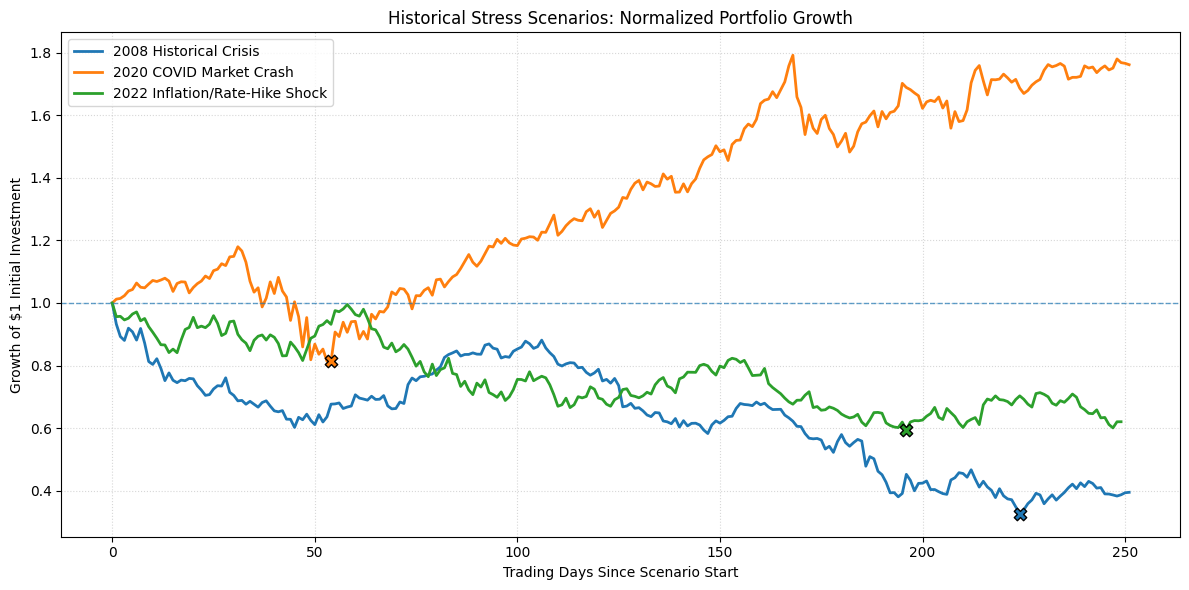

In [19]:
# --- Normalized Stress Scenario Visualization ---
plt.figure(figsize=(12, 6))

for name, result in scenario_results.items():
  growth = result['growth']
  normalized_growth = (growth /growth.iloc[0]).reset_index(drop=True)

  plt.plot(normalized_growth, label=name, lw=2)

  trough_idx = normalized_growth.idxmin()
  plt.scatter(trough_idx, normalized_growth.iloc[trough_idx], marker='X', s=80,
              edgecolor='black', zorder=5)

plt.axhline(1, linestyle="--", linewidth=1, alpha=0.7)
plt.title("Historical Stress Scenarios: Normalized Portfolio Growth")
plt.xlabel("Trading Days Since Scenario Start")
plt.ylabel("Growth of $1 Initial Investment")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

> Each historical scenario is normalized to a common starting value of 1.0 so that portfolio paths can be compared by trading days elapsed rather calendar date

## 9. VaR BACKTESTING & EXCEPTION ANALYSIS
>Objective: Evaluate whether the VaR model produces an appropriate frequency of exceptions.

In [20]:
def backtest_var(returns, c=0.95):
  p = 1 - c
  N = len(returns)

  # -- Exception Counting --
  var = np.quantile(returns, p)
  var_forecasts = pd.Series(abs(var), index=returns.index)
  exceptions = returns < -var_forecasts
  x = int(exceptions.sum())
  p_hat = x / N

  # -- Kupiec POF Test --
  if x == 0:
    lr_pof = -2 * N * np.log(c)
  elif x == N:
    lr_pof = -2 * N * np.log(p)
  else:
    null_log = (N - x) * np.log(c) + x * np.log(p)
    alt_log = (N - x) * np.log(1 - p_hat) + x * np.log(p_hat)
    lr_pof = -2 * (null_log - alt_log)

  # -- Basel Traffic Light Zone --
  p_value = 1 - stats.chi2.cdf(lr_pof, df=1)
  cum_prob = stats.binom.cdf(x, N, p)
  expected_x = N * p

  if c == 0.99 and N == 250:
      if x <= 4:
        basel_zone, multiplier_penalty = '🟢 Green (Accurate)', 0.00
      elif 5 <= x <= 10:
        basel_zone, multiplier_penalty = '🟡 Yellow (Underestimating Risk)', 0.40
      else:
        basel_zone, multiplier_penalty = '🔴 Red (Broken)', 1.00
  else:
      if cum_prob <= 0.95:
        basel_zone, multiplier_penalty = '🟢 Green', 0.00
      elif 0.95 < cum_prob < 0.9999:
        basel_zone = '🟡 Yellow'
        multiplier_penalty = round(((cum_prob - 0.95) / (0.9999 - 0.95)) * 1.0, 2)
      else:
        basel_zone, multiplier_penalty = '🔴 Red', 1.00

  return {
        "Total Observations": N,
        "Observed Exceptions": x,
        "Expected Exceptions": round(expected_x, 2),
        "Empirical Failure Rate": f"{p_hat:.2%}",
        "Kupiec LR Statistic": round(lr_pof, 4),
        "Kupiec p-value": round(p_value, 4),
        "Model Rejected (H0)": bool(p_value < 0.05),
        "Basel Traffic Zone": basel_zone,
        "Capital Multiplier Penalty": multiplier_penalty,
        "Basel Cumulative Probability": round(cum_prob, 4),
        "Exception Mask": exceptions,
        'VaR Forecast Series' : var_forecasts
    }

In [21]:
backtest_results = backtest_var(port_returns)

df_results = pd.DataFrame(backtest_results, index=["Value"]).T


backtest_df = df_results.drop(["Exception Mask", "VaR Forecast Series"])
backtest_df

,Value
Total Observations,1253
Observed Exceptions,63
Expected Exceptions,62.65
Empirical Failure Rate,5.03%
Kupiec LR Statistic,0.0021
Kupiec p-value,0.9638
Model Rejected (H0),False
Basel Traffic Zone,🟢 Green
Capital Multiplier Penalty,0.0
Basel Cumulative Probability,0.5515


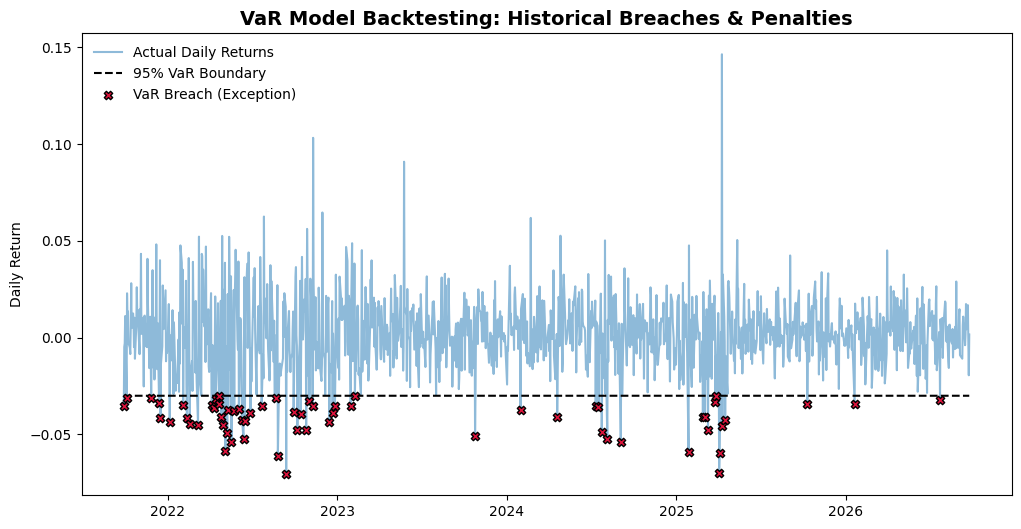

In [22]:
plt.figure(figsize=(12, 6))

plt.plot(port_returns, label='Actual Daily Returns', alpha=0.5)
plt.plot(-backtest_results['VaR Forecast Series'], label='95% VaR Boundary', color='black', ls='--')

exceptions_series = port_returns[backtest_results['Exception Mask']]
plt.scatter(exceptions_series.index, exceptions_series, marker='X', edgecolor='black',
            color='crimson', label='VaR Breach (Exception)', zorder=3)

plt.title("VaR Model Backtesting: Historical Breaches & Penalties", fontsize=14, fontweight="bold")
plt.ylabel("Daily Return")
plt.legend(loc='upper left', frameon=False)
plt.show()

##  10. PORTFOLIO RISK CONTRIBUTION & CONCENTRATION
>Objective: Identify how portfolio-level VaR is distributed across individual assets and measure concentration.

In [23]:
def calculate_risk_decomposition(weights, returns, c=0.95):
  cov_matrix = returns.cov()
  port_vol = np.sqrt(weights.T @ cov_matrix @ weights)

  z_score = stats.norm.ppf(c)
  port_var = port_vol * z_score

  marginal_var = z_score * ((cov_matrix @ weights) / port_vol)
  component_var = weights * marginal_var
  pct_component_var = component_var / port_var

  hhi = np.sum(weights ** 2)
  max_holding = np.max(weights)
  effective_n = 1.0 / hhi

  decomposition_df = pd.DataFrame({
      'Weight' : weights,
      'Marginal VaR' : marginal_var,
      'Component VaR' : component_var,
      'Risk Contribution %' : pct_component_var
  }, index=returns.columns)

  concentrtation_metrics = {
      'Largest Holding' : f'{max_holding:.2%}',
      'Herfindahl-Hirschman Index (HHI)' : f'{hhi:.2f}',
      'Effective N Assets' : effective_n,
      'Illustrative Concentration Status' : (
          'Highly Concentrated' if hhi > 0.25
          else 'Moderately Concentrated' if hhi > 0.15
          else 'Well Diversified'
      ),
       }

  return {
      'decomposition' : decomposition_df,
      'concentration' : concentrtation_metrics,
      'port_var' : port_var,
  }

In [24]:
risk_results = calculate_risk_decomposition(equal_weights, daily_returns)

risk_df = risk_results['decomposition']
concentration = risk_results['concentration']
portfolio_var = risk_results['port_var']

print("--- Concentration Analytics ---")
print(f"Total Portfolio VaR: {portfolio_var:.2%}")
print(f"Largest Holding: {concentration['Largest Holding']}")
print(f"HHI: {concentration['Herfindahl-Hirschman Index (HHI)']}")
print(f"Effective N Assets: {concentration['Effective N Assets']:.2f}")
print(f"Status: {concentration['Illustrative Concentration Status']}\n")

print("--- Risk Contribution Breakdown ---")
risk_df.style.format({
    "Weight": "{:.2%}",
    "Marginal VaR": "{:.4f}",
    "Component VaR": "{:.4f}",
    "Risk Contribution %": "{:.2%}"
})

--- Concentration Analytics ---
Total Portfolio VaR: 3.18%
Largest Holding: 33.33%
HHI: 0.33
Effective N Assets: 3.00
Status: Highly Concentrated

--- Risk Contribution Breakdown ---


,Weight,Marginal VaR,Component VaR,Risk Contribution %
Ticker,,,,
AAPL,33.33%,0.0218,0.0073,22.86%
GOOG,33.33%,0.0261,0.0087,27.36%
NVDA,33.33%,0.0475,0.0158,49.78%


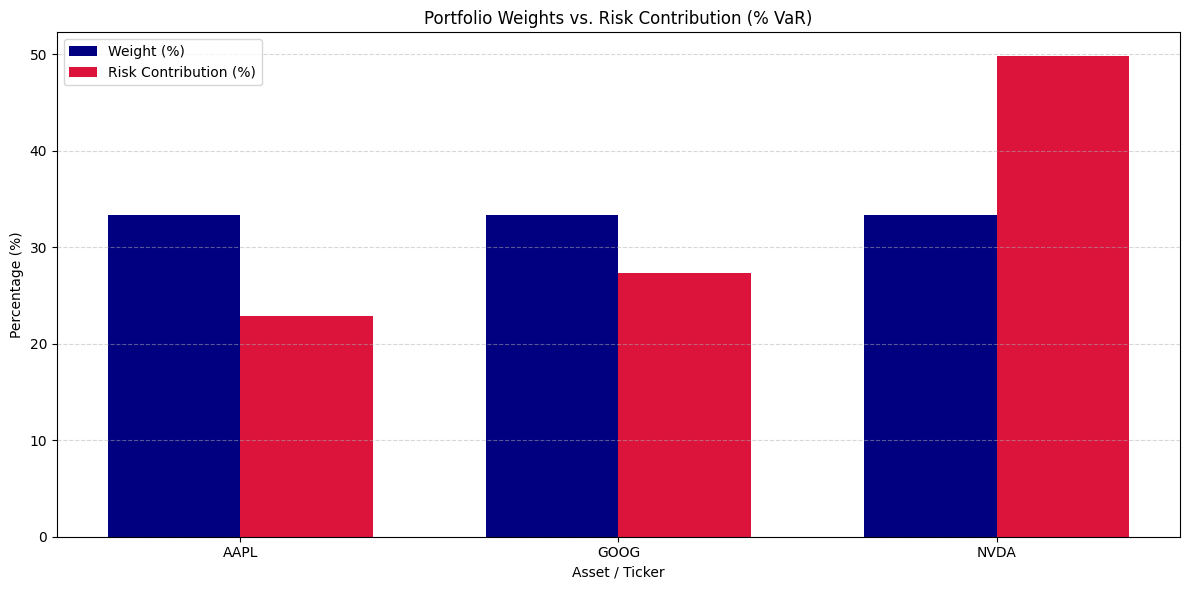

In [25]:
plt.figure(figsize=(12, 6))

assets = risk_df.index
weights = risk_df['Weight'] * 100
risk_contrib = risk_df['Risk Contribution %'] * 100

x = range(len(assets))
width = 0.35

plt.bar([i - width/2 for i in x], weights, width=width, label='Weight (%)', color='navy')
plt.bar([i + width/2 for i in x], risk_contrib, width=width, label='Risk Contribution (%)', color='crimson')

plt.title('Portfolio Weights vs. Risk Contribution (% VaR)')
plt.xlabel('Asset / Ticker')
plt.ylabel('Percentage (%)')
plt.xticks(x, assets)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 11. ROLLING / TIME-VARYING PARAMETRIC RISK
>Objective: Monitor how etimated portfolio risk changes through time using rolling parametric risk measures.

In [26]:
def rolling_risk_metrics(returns, window=60, c=0.95):
  p = 1 - c
  z_score = stats.norm.ppf(c)
  pdf_z = stats.norm.pdf(z_score)

  rolling_mean = returns.rolling(window=window).mean()
  rolling_std = returns.rolling(window=window).std()

  rolling_var = - (rolling_mean - (rolling_std * z_score))
  rolling_cvar = - (rolling_mean - (rolling_std * (pdf_z / p)))

  rolling_df = pd.DataFrame({
      'Portfolio Returns' : returns,
      'Rolling Mean' : rolling_mean,
      'Rolling Std' : rolling_std,
      'Rolling VaR' : rolling_var,
      'Rolling CVaR' : rolling_cvar
  }).dropna()

  return rolling_df

rolling_df = rolling_risk_metrics(port_returns)
rolling_df.index = pd.to_datetime(rolling_df.index).date
rolling_df.tail().style.format('{:.2%}')

,Portfolio Returns,Rolling Mean,Rolling Std,Rolling VaR,Rolling CVaR
2026-09-18,0.43%,0.16%,1.21%,1.82%,2.33%
2026-09-21,1.67%,0.24%,1.15%,1.66%,2.14%
2026-09-22,-0.03%,0.24%,1.15%,1.66%,2.14%
2026-09-23,-1.95%,0.18%,1.17%,1.74%,2.23%
2026-09-24,0.15%,0.15%,1.14%,1.73%,2.21%


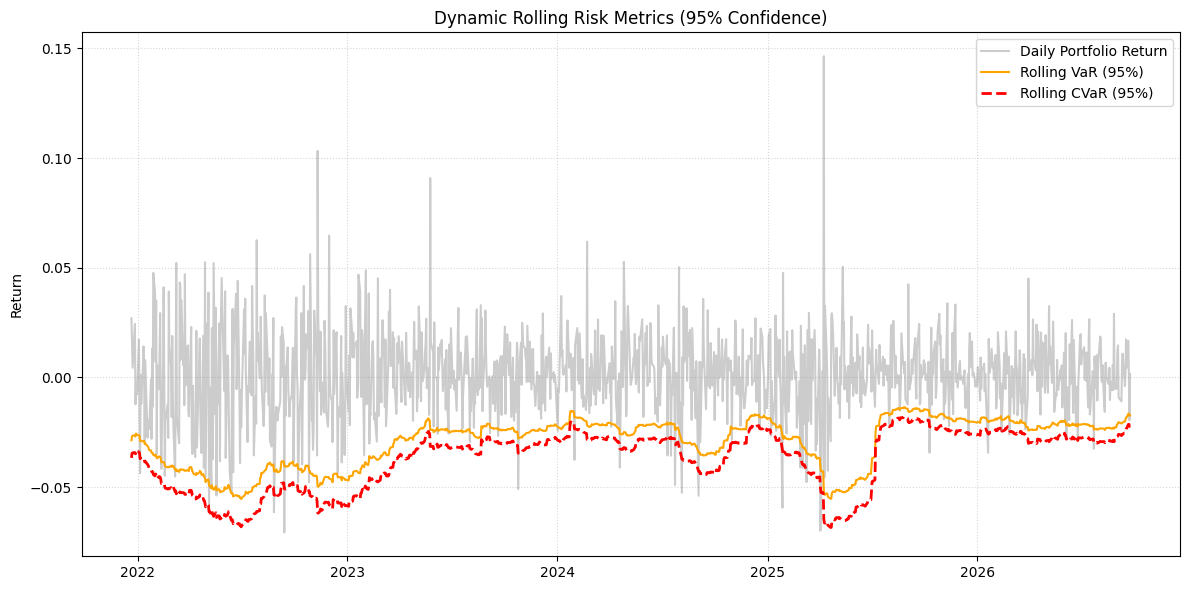

In [27]:
# -- Visualization: Rolling Risk Metrics --
plt.figure(figsize=(12, 6))

plt.plot(rolling_df.index, rolling_df['Portfolio Returns'],
        color='gray', alpha=0.4, label='Daily Portfolio Return')

plt.plot(rolling_df.index, -rolling_df["Rolling VaR"],
        color='orange', linewidth=1.5,
                        label=f"Rolling VaR (95%)")
plt.plot(rolling_df.index, -rolling_df["Rolling CVaR"],
        color='red', linewidth=2, linestyle='--',
                     label=f"Rolling CVaR (95%)")


plt.title(f"Dynamic Rolling Risk Metrics (95% Confidence)")
plt.ylabel("Return")
plt.legend(loc="best")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 12. TAIL RISK & RISK-ADJUSTED PERFORMANCE
>Objective: Examine return distribution characteristics and evaluate performance relative to volatility, downside risk, and drawdown.

In [28]:
def tail_and_performance_metrics(returns, max_drawdown, rf=0):
  skew = returns.skew()
  kurtosis = returns.kurtosis()

  jb_test, jb_pvalue = stats.jarque_bera(returns)
  is_normal = jb_pvalue >= 0.05

  downside_returns = np.minimum(returns, 0)
  downside_std = np.sqrt((downside_returns ** 2).mean()) * np.sqrt(252)

  annual_returns = returns.mean() * 252
  annual_vol = returns.std() * np.sqrt(252)

  sharpe_ratio = (annual_returns - rf) / annual_vol if annual_vol != 0 else 0
  sortino_ratio = (annual_returns - rf) / downside_std if downside_std != 0 else 0
  calmar_ratio = annual_returns / abs(max_drawdown) if abs(max_drawdown) != 0 else 0

  metrics_df = pd.DataFrame({
      'Skewness': skew,
        'Kurtosis': kurtosis,
        'Jarque-Bera Test Statistic': jb_test,
        'Jarque-Bera p-value': jb_pvalue,
        'Is Normally Distributed?': is_normal,
        'Annualized Return': annual_returns,
        'Annualized Volatility': annual_vol,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio
  }, index=['Value'])

  return metrics_df

metrics_df = tail_and_performance_metrics(port_returns, max_drawdown, rf=0)
metrics_df.T


,Value
Skewness,0.348967
Kurtosis,3.903451
Jarque-Bera Test Statistic,812.594775
Jarque-Bera p-value,0.0
Is Normally Distributed?,False
Annualized Return,0.349056
Annualized Volatility,0.306905
Sharpe Ratio,1.137344
Sortino Ratio,1.7233
Calmar Ratio,0.828597


> The Jarque-Bera test evaluates whether protfolio returns are consistent with a normal distribution based on skewness and kurtosis; the result is used as a diagnostic rather than defintive proof of model suitability

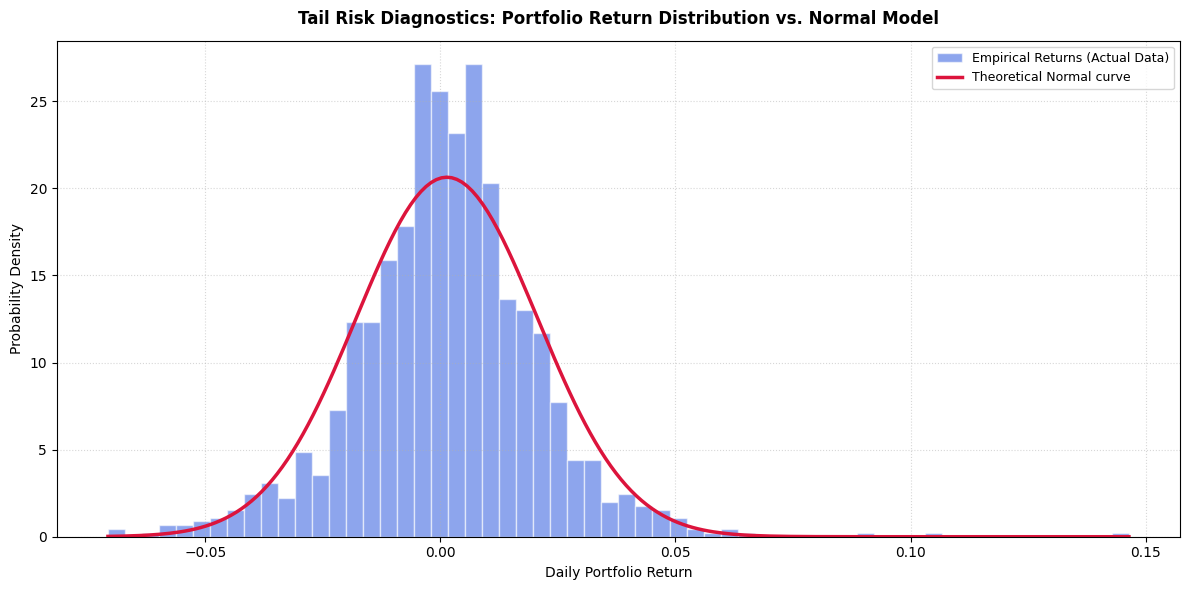

In [29]:
# -- Visualization: Rolling Risk Metrics --
plt.figure(figsize=(12, 6))

plt.hist(port_returns, bins=60, density=True, alpha=0.6,
        color='royalblue', edgecolor='white',
                      label='Empirical Returns (Actual Data)')

mu, std = stats.norm.fit(port_returns)
x_axis = np.linspace(port_returns.min(), port_returns.max(), 200)
normal_curve = stats.norm.pdf(x_axis, mu, std)

plt.plot(x_axis, normal_curve, linewidth=2.5, color='crimson',
        label='Theoretical Normal curve')

plt.title('Tail Risk Diagnostics: Portfolio Return Distribution vs. Normal Model',
         fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Daily Portfolio Return', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.legend(loc="upper right", frameon=True, fontsize=9)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

## 13. RISK REPORT & RISK-LIMIT STATUS
>Objective: Consolidate model outputs into an executive-style risk-limit and portfolio-risk report.

In [30]:
def generate_executive_risk_report(
    compare_df,
    port_returns,
    hist_max_dd,
    stressed_max_dd,
    stress_matrix,
    backtest_results,
    concentration,
    rolling_df,
    tail_perf_metrics
):
    # ---------------------------------------------------------
    # 1. EXTRACT & PREPARE RAW METRICS
    # ---------------------------------------------------------
    row_key = "Historical 1-Day" if "Historical 1-Day" in compare_df.index else compare_df.index[0]
    hist_var_95 = compare_df.loc[row_key, "95% VaR"]
    hist_cvar_95 = compare_df.loc[row_key, "95% CVaR"]

    ann_vol_val = port_returns.std() * np.sqrt(252)

    def clean_val(x):
        return float(str(x).replace('%', '')) / 100 if '%' in str(x) else float(x)

    largest_holding = clean_val(concentration["Largest Holding"])
    hhi_val = clean_val(concentration["Herfindahl-Hirschman Index (HHI)"])

    basel_zone = backtest_results.get("Basel Traffic Zone", "Green")
    exceptions = backtest_results.get("Observed Exceptions", 0)

    # ---------------------------------------------------------
    # 2. BUILD RISK-LIMIT COMPLIANCE MATRIX
    # ---------------------------------------------------------
    limits_data = [
        {"Risk Limit": "1-Day 95% VaR", "Policy Limit": "3.50%", "Actual Metric": f"{hist_var_95:.2%}", "Status": "⚠️ BREACH" if hist_var_95 > 0.035 else "🟢 PASS"},
        {"Risk Limit": "1-Day 95% CVaR", "Policy Limit": "4.50%", "Actual Metric": f"{hist_cvar_95:.2%}", "Status": "⚠️ BREACH" if hist_cvar_95 > 0.045 else "🟢 PASS"},
        {"Risk Limit": "Historical Max Drawdown", "Policy Limit": "45.00%", "Actual Metric": f"{abs(hist_max_dd):.2%}", "Status": "⚠️ BREACH" if abs(hist_max_dd) > 0.45 else "🟢 PASS"},
        {"Risk Limit": "Annualized Volatility", "Policy Limit": "25.00%", "Actual Metric": f"{ann_vol_val:.2%}", "Status": "⚠️ BREACH" if ann_vol_val > 0.25 else "🟢 PASS"},
        {"Risk Limit": "Single-Asset Concentration", "Policy Limit": "35.00%", "Actual Metric": f"{largest_holding:.2%}", "Status": "⚠️ BREACH" if largest_holding > 0.35 else "🟢 PASS"},
        {"Risk Limit": "Herfindahl-Hirschman Index (HHI)", "Policy Limit": "0.2500", "Actual Metric": f"{hhi_val:.4f}", "Status": "⚠️ BREACH" if hhi_val > 0.25 else "🟢 PASS"},
        {"Risk Limit": "VaR Backtest Exception Status", "Policy Limit": "🟢 Green Zone (≤4 exceptions)", "Actual Metric": f"{exceptions} exceptions ({basel_zone})", "Status": "🟢 PASS" if "Green" in str(basel_zone) else "⚠️ BREACH"}
    ]
    df_limits = pd.DataFrame(limits_data)

    # ---------------------------------------------------------
    # 3. BUILD EXECUTIVE RISK SUMMARY DASHBOARD
    # ---------------------------------------------------------
    var_col = [c for c in rolling_df.columns if "VaR" in c and "CVaR" not in c][0]
    cvar_col = [c for c in rolling_df.columns if "CVaR" in c][0]

    latest_var, avg_var = rolling_df[var_col].iloc[-1], rolling_df[var_col].mean()
    latest_cvar, avg_cvar = rolling_df[cvar_col].iloc[-1], rolling_df[cvar_col].mean()

    worst_crisis = stress_matrix["Maximum Drawdown"].idxmin()
    worst_crisis_dd = stress_matrix.loc[worst_crisis, "Maximum Drawdown"]

    is_normal_val = tail_perf_metrics["Is Normally Distributed?"].values[0]
    sortino_val = float(tail_perf_metrics["Sortino Ratio"].values[0])
    calmar_val = float(tail_perf_metrics["Calmar Ratio"].values[0])

    summary_data = [
        {"Category": "Risk & Tail Limits (Ph 2/6)", "Metric": "Historical 95% VaR / CVaR", "Value": f"{hist_var_95:.2%} / {hist_cvar_95:.2%}"},
        {"Category": "Drawdown Profile (Ph 7)", "Metric": "Hist Max DD / Stressed 95% DD", "Value": f"{abs(hist_max_dd):.2%} / {abs(stressed_max_dd):.2%}"},
        {"Category": "Stress Scenario Test (Ph 8)", "Metric": f"Worst Stress Scenario ({worst_crisis}) DD", "Value": f"{worst_crisis_dd:.2%}"},
        {"Category": "Model Reliability (Ph 9)", "Metric": "Exception Status / Kupiec p-value", "Value": f"{basel_zone} (p={backtest_results['Kupiec p-value']:.4f})"},
        {"Category": "Portfolio Structure (Ph 10)", "Metric": "Illustrative Concentration Status (Top Asset)", "Value": f"{concentration['Illustrative Concentration Status']} ({concentration['Largest Holding']})"},
        {"Category": "Regime Indicator (Ph 11)", "Metric": "Current VaR vs Avg (Regime)", "Value": f"{latest_var:.2%} vs {avg_var:.2%} ({'Elevated' if latest_var > avg_var else 'Calm'})"},
        {"Category": "Regime Indicator (Ph 11)", "Metric": "Current CVaR vs Avg", "Value": f"{latest_cvar:.2%} vs {avg_cvar:.2%}"},
        {"Category": "Distribution & Performance (Ph 12)", "Metric": "Is Normal Distributed?", "Value": str(is_normal_val)},
        {"Category": "Distribution & Performance (Ph 12)", "Metric": "Sortino / Calmar Ratio", "Value": f"{sortino_val:.2f} / {calmar_val:.2f}"}
    ]
    df_summary = pd.DataFrame(summary_data)

    # ---------------------------------------------------------
    # 4. PRINT REPORT OUT TO CONSOLE
    # ---------------------------------------------------------
    print("=" * 65)
    print("             PART 1: RISK-LIMIT COMPLIANCE MATRIX")
    print("=" * 65)
    print(df_limits.to_string(index=False))

    print("\n" + "=" * 65)
    print("             PART 2: EXECUTIVE RISK SUMMARY DASHBOARD")
    print("=" * 65)
    print(df_summary.to_string(index=False))

    return {"limits_table": df_limits, "executive_summary": df_summary}


In [31]:
report_output = generate_executive_risk_report(
    compare_df=var_cvar_summary,
    port_returns=port_returns,      # Pass your Series/DataFrame of daily returns
    hist_max_dd=max_drawdown,
    stressed_max_dd=drawdown_95_threshold,    # Your 95% Stressed VaR/DD from Phase 7
    stress_matrix=stress_matrix,     # Your stress testing results table from Phase 8
    backtest_results=backtest_results,   # Your dictionary containing Basel/Kupiec from Phase 9
    concentration=concentration,    # Your dictionary containing HHI/Largest Holding from Phase 10
    rolling_df=rolling_df,          # Your rolling VaR/CVaR window DataFrame from Phase 11
    tail_perf_metrics=metrics_df    # Your Phase 12 distribution/ratio DataFrame
)


             PART 1: RISK-LIMIT COMPLIANCE MATRIX
                      Risk Limit                 Policy Limit           Actual Metric    Status
                   1-Day 95% VaR                        3.50%                   3.01%    🟢 PASS
                  1-Day 95% CVaR                        4.50%                   4.20%    🟢 PASS
         Historical Max Drawdown                       45.00%                  42.13%    🟢 PASS
           Annualized Volatility                       25.00%                  30.69% ⚠️ BREACH
      Single-Asset Concentration                       35.00%                  33.33%    🟢 PASS
Herfindahl-Hirschman Index (HHI)                       0.2500                  0.3300 ⚠️ BREACH
   VaR Backtest Exception Status 🟢 Green Zone (≤4 exceptions) 63 exceptions (🟢 Green)    🟢 PASS

             PART 2: EXECUTIVE RISK SUMMARY DASHBOARD
                          Category                                            Metric                        Value
       Risk &

> Risk-limit framework: The limits below are illustrative policy thresholds created for this project to demonstrate risk-limit monitoring. They are not intended to represent regulatory requirements or investment recommendations.